Author: Julia Jurkowska

## Source localization and signal reconstruction - case study for oddball data

### Introduction
In this tutorial, we will learn how to **localize sources** from EEG data and **reconstruct signals** at those sources using **MVPURE_py**, an extension to MNE-Python.
Source localization allows us to move beyond sensor-level analysis to estimate where in the brain the measured activity originates. Once sources are identified, we can reconstruct time series from vertices of interest for further analysis.

We will cover the following steps:
1. Reading all necessary data for the ``sample_subject``. You can download this dataset [here](https://figshare.com/articles/dataset/Sample_subject_data_/30102451?file=57853861).
2. Computing data and noise covariance (R and N, respectively).
3. Analysis of $RN^{-1}$ eigenvalues to guide the number of sources to localize and select an appropriate optimization parameter.
4. Localizing the specified number of sources.
5. Reconstructing source signals for vertices of interest and plotting the results.

All steps will be repeated for two time frames: "sensory" (50-200 ms after stimuli) and "cognitive" (350-600 ms after stimuli).

By the end of this tutorial, you will understand the basic workflow of source localization and signal reconstruction using the MVPURE-py package.

In [1]:
import mne
import os

mne.viz.set_3d_backend('pyvistaqt')

from mvpure_py import localizer, viz, utils

Using pyvistaqt 3d backend.


We will use data the ``sample_subject`` dataset [provided on Figshare](https://figshare.com/articles/dataset/Sample_subject_data_/30102451?file=57853861). If you wish to start from the beginning, please complete tutorial [Preprocessing data from oddball paradigm](https://julia-jurkowska.github.io/mvpure-tools/tutorials/preprocessing_data_from_oddball_paradigm.html) first.

In [2]:
subject = "sample_subject"
subjects_dir = "subjects"
mne.set_config('SUBJECTS_DIR', subjects_dir)

# Reading mne.Epochs
epoched = mne.read_epochs(os.path.join(subjects_dir, subject, "_eeg", "_pre", f"{subject}_oddball-epo.fif"))
forward_path = os.path.join(subjects_dir, subject, "forward", f"{subject}_ico4-fwd.fif")
trans_path = os.path.join(subjects_dir, subject, "_eeg", "trans", f"{subject}-fit_trans.fif")

# We will be using only data for 'target' stimuli
target = epoched['target']
sel_epoched = target.copy()
sel_epoched = sel_epoched.set_eeg_reference('average', projection=True)
sel_epoched.apply_proj()
sel_evoked = sel_epoched.average()

Reading /Volumes/UMK/oddball/subjects/sample_subject/_eeg/_pre/sample_subject_oddball-epo.fif ...
    Found the data of interest:
        t =    -199.22 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
621 matching events found
No baseline correction applied
0 projection items activated
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


To perform source localization, we need a **forward model** that links activity at source locations to the sensors (in this case EEG channels).
Here, we load the forward solution and convert it to a fixed-orientation representation.

In [3]:
# Reading mne.Forward 
fwd_vector = mne.read_forward_solution(forward_path)

# Using fixed orientation in forward solution
fwd = mne.convert_forward_solution(
    fwd_vector,
    surf_ori=True,
    force_fixed=True,
    use_cps=True
)
   
# Leadfield matrix
leadfield = fwd["sol"]["data"]

# Source positions extracted from forward model
src = fwd["src"]

Reading forward solution from /Volumes/UMK/oddball/subjects/sample_subject/forward/sample_subject_ico4-fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (5124 sources, 128 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Changing to fixed-orientation forward solution with surface-based source orientations...
    [done]


### "Sensory" processing
We will start with analysing processes in "sensory" time window.

In an oddball paradigm, participants are presented with a sequence of frequent (standard) and infrequent (target) stimuli. The early neural responses to these target stimuli reflect **sensory processing** - the brain's initial registration of the incoming stimulus before higher-level cognitive mechanisms are engaged.
We assume that sensory processing for given oddball paradigm occurs within the **50-200 ms** window after the stimuli. We will therefore compute the data covariance in this time range.
To estimate the noise covariance, we use a baseline period **-200ms to 0 ms**, i.e., the interval before stimulus onset. This baseline is assumed to be free of stimulus-locked activity and provides reference for separating signal from noise.

In [4]:
# Compute noise covariance
noise_cov = mne.compute_covariance(
    sel_epoched,
    tmin=-0.2,
    tmax=0,
    method="empirical"
)

# Compute data covariance for range corresponding to sensory processing
data_cov_sen = mne.compute_covariance(
    sel_epoched,
    tmin=0.05,
    tmax=0.2,
    method="empirical"
)

# Subset signal for given time range
signal_sen = sel_evoked.crop(
    tmin=0.05,
    tmax=0.2
)

    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 128 -> 127
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 4056
[done]
    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 128 -> 127
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 3042
[done]


#### $RN^{-1}$ eigenvalues analysis
Before localization, we examine the eigenvalue spectrum of the whitened data covariance (RN⁻¹). Large eigenvalues indicate signal-dominated subspace; small ones reflect noise.

The plot shows:
- **Eigenvalues vs. rank**: Helps determine optimal number of sources
- **Signal/noise separation**: Drop-off indicates transition between signal and noise eigenvalues

For technical details on eigenvalue-based rank selection, see the [MVPURE paper](https://arxiv.org/pdf/2509.14118).

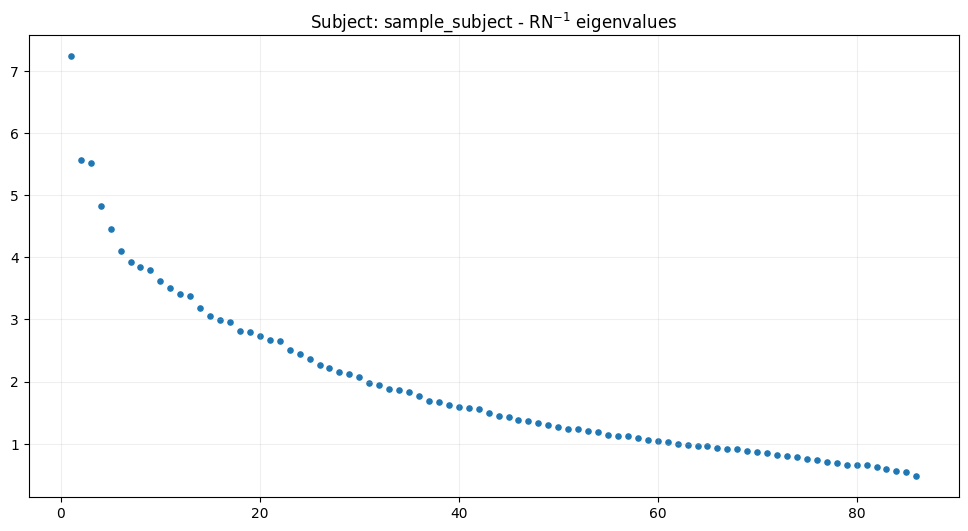

In [5]:
fig_RN = viz.plot_RN_eigenvalues(
    R=data_cov_sen.data,
    N=noise_cov.data,
    subject=subject,
    s=14
)

#### Localize
Based on the eigenvalue spectrum above, we will localize $l_0=5$ sources.
We will use function ```mvpure_py.localizer.localize```, which performs the actual source localization.
The main parameters are: 
- ``subject``: the subject ID (here: ``"sample_subject"``)
- ``subjects_dir``: directory containing the subject folders.
- ``localizer_to_use``: the algorithm variant. Here we choose ``"mai_mvp"``. For details, see [paper](https://arxiv.org/pdf/2509.14118) or the function documentation.
- ``n_sources_to_localize``: number of sources to localize.
- ``R``: data covariance matrix
- ``N``: noise covariance matrix
- ```forward```: the ``mne.Forward`` object for this subject
- ``r``: optimization rank parameter. We will use list of ranks, therefore finally localized sources will be vertices localized in at least one iteration.

In [6]:
l_0 = 5

locs_sen = localizer.localize(
    subject=subject,
    subjects_dir=subjects_dir,
    localizer_to_use=["mai_mvp"],
    n_sources_to_localize=l_0,
    R=data_cov_sen.data,
    N=noise_cov.data,
    forward=fwd,
    r=list(range(1,  l_0+1))
)

Rank: 1
Calculating activity index for localizer: mai_mvp


iter 5/5: 100%|██████████| 5124/5124 [00:00<00:00, 10730.55it/s]



[Activity Index Result]
  Selected indices (index_max): [31, 2697, 2042, 2747, 2554]
  Index max values: [1.21021186 1.45630239 1.65413543 1.8810501  1.98695636]
  Rank parameter (r): 1

Rank: 2
Calculating activity index for localizer: mai_mvp


iter 5/5: 100%|██████████| 5124/5124 [00:00<00:00, 11429.69it/s]



[Activity Index Result]
  Selected indices (index_max): [31, 2597, 4765, 2029, 2779]
  Index max values: [1.21021186 2.22236888 2.50811308 2.7559683  2.98024038]
  Rank parameter (r): 2

Rank: 3
Calculating activity index for localizer: mai_mvp


...


[Activity Index Result]
  Selected indices (index_max): [31, 2597, 1837, 4836, 1622]
  Index max values: [1.21021186 2.22236888 3.19893305 3.49029219 3.76719894]
  Rank parameter (r): 3

Rank: 4
Calculating activity index for localizer: mai_mvp


iter 5/5: 100%|██████████| 5124/5124 [00:00<00:00, 14458.82it/s]



[Activity Index Result]
  Selected indices (index_max): [31, 2597, 1837, 3557, 2042]
  Index max values: [1.21021186 2.22236888 3.19893305 4.14451814 4.49089945]
  Rank parameter (r): 4

Rank: 5
Calculating activity index for localizer: mai_mvp


iter 5/5: 100%|██████████| 5124/5124 [00:00<00:00, 15790.73it/s]


[Activity Index Result]
  Selected indices (index_max): [31, 2597, 1837, 3557, 1966]
  Index max values: [1.21021186 2.22236888 3.19893305 4.14451814 5.04837914]
  Rank parameter (r): 5


In [7]:
# Optional visualization

# locs_sen.plot_localized_sources()

#### Signal reconstruction

With sources localized, we reconstruct their time courses using LCMV beamforming:

1. **Restrict forward model** to localized vertices only
2. **Build LCMV filters** using unit-noise-gain normalization
3. **Apply filters** to evoked data


In [8]:
new_fwd = utils.subset_forward(
    old_fwd=fwd,
    localized=locs_sen,
    hemi="both"
)

In [9]:
lcmv = mne.beamformer.make_lcmv(
    signal_sen.info,
    new_fwd,
    data_cov_sen,
    reg=0.05,
    noise_cov=noise_cov,
    pick_ori=None,  # not needed with fixed orientation forward
    weight_norm="nai",
    rank=None
)
stc_lcmv = mne.beamformer.apply_lcmv(signal_sen, lcmv)

Computing rank from covariance with rank=None
    Using tolerance 4.4e-13 (2.2e-16 eps * 128 dim * 15  max singular value)
    Estimated rank (eeg): 86
    EEG: rank 86 computed from 128 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 3.6e-13 (2.2e-16 eps * 128 dim * 13  max singular value)
    Estimated rank (eeg): 86
    EEG: rank 86 computed from 128 data channels with 1 projector
Making LCMV beamformer with rank {'eeg': 86}
Computing inverse operator with 128 channels.
    128 out of 128 channels remain after picking
Selected 128 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank={'eeg': 86}
    Setting small EEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 14 sources
Filter computation complete


Then we attach the resulting ``mne.SourceEstimate`` to the localized sources object, making it easier to visualize:

Finally, let's plot the localized sources with their reconstructed activity:

In [10]:
viz.plot_sources_with_activity(
    subject=subject,
    stc=stc_lcmv
)

Using control points [0.92516798 1.13740896 1.58862482]


### "Cognitive" task
After examining the early sensory responses, we now turn to the later cognitive stage of processing in the oddball paradigm.
In EEG, target stimuli typically evoke a P300 component — a positive deflection peaking around 300–600 ms after stimulus onset.
This response is thought to reflect higher-level cognitive processes, such as attention allocation and stimulus evaluation, in contrast to the earlier sensory responses.

For this dataset, we will therefore define the cognitive time window as **350–600 ms**.
The pipeline remains the same as before:

- Compute noise covariance (always from −200 to 0 ms).
- Compute data covariance in the cognitive window (350–600 ms).
- Subset the evoked signal to this time range.

In [11]:
# Compute data covariance for range corresponding to sensory processing
data_cov_task = mne.compute_covariance(
    sel_epoched,
    tmin=0.35,
    tmax=0.6,
    method="empirical"
)
# There's no need to compute `noise_covariance` again as it is the same time interval

sel_evoked = sel_epoched.average()

# Subset signal for given time range
signal_task = sel_evoked.crop(
    tmin=0.35,
    tmax=0.6
)

    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 128 -> 127
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 5070
[done]


From here, we can repeat the same steps as in the sensory section:
- analyze eigenvalues of $RN^{-1}$,
- localize sources,
- reconstruct signals with LCMV-NAI beamformer,
- and finally visualize the results.

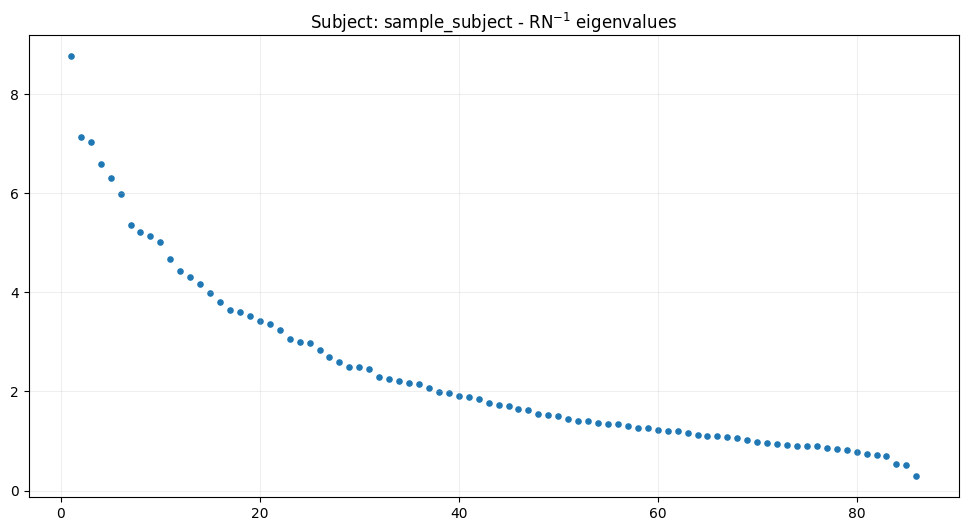

In [12]:
fig_RN_task = viz.plot_RN_eigenvalues(
    R=data_cov_task.data,
    N=noise_cov.data,
    subject=subject,
    s=14
)

In [13]:
l_0 = 10

# Localize
locs_task = localizer.localize(
    subject=subject,
    subjects_dir=subjects_dir,
    localizer_to_use=["mai_mvp"],
    n_sources_to_localize=l_0,
    R=data_cov_task.data,
    N=noise_cov.data,
    forward=fwd,
    r=list(range(1, l_0 + 1)),
)

Rank: 1
Calculating activity index for localizer: mai_mvp


iter 10/10: 100%|██████████| 5124/5124 [00:00<00:00, 12554.05it/s]



[Activity Index Result]
  Selected indices (index_max): [2160, 4755, 419, 1240, 996, 1546, 3978, 3790, 3861, 441]
  Index max values: [1.77758988 2.25869353 2.55953156 2.85677162 2.98744644 3.06891462
 3.13975703 3.20066062 3.3391399  3.48255084]
  Rank parameter (r): 1

Rank: 2
Calculating activity index for localizer: mai_mvp


iter 10/10: 100%|██████████| 5124/5124 [00:00<00:00, 13824.29it/s]



[Activity Index Result]
  Selected indices (index_max): [2160, 2300, 4897, 4755, 419, 1808, 2461, 1240, 2248, 2834]
  Index max values: [1.77758988 3.2754443  4.04566418 4.46424172 4.79131535 5.08992702
 5.34796421 5.62534082 5.86618604 6.15678146]
  Rank parameter (r): 2

Rank: 3
Calculating activity index for localizer: mai_mvp


...


[Activity Index Result]
  Selected indices (index_max): [2160, 2300, 4755, 1368, 1689, 1835, 1875, 4405, 4701, 4231]
  Index max values: [ 1.77758988  3.2754443   4.85038569  6.4063041   7.90005161  9.38758629
 10.84390766 12.2470246  12.9417525  13.68085168]
  Rank parameter (r): 8

Rank: 9
Calculating activity index for localizer: mai_mvp


iter 10/10: 100%|██████████| 5124/5124 [00:00<00:00, 14883.10it/s]



[Activity Index Result]
  Selected indices (index_max): [2160, 2300, 4755, 1368, 1689, 1835, 1875, 4405, 600, 4701]
  Index max values: [ 1.77758988  3.2754443   4.85038569  6.4063041   7.90005161  9.38758629
 10.84390766 12.2470246  13.62102771 14.3351125 ]
  Rank parameter (r): 9

Rank: 10
Calculating activity index for localizer: mai_mvp


iter 10/10: 100%|██████████| 5124/5124 [00:00<00:00, 17827.32it/s]


[Activity Index Result]
  Selected indices (index_max): [2160, 2300, 4755, 1368, 1689, 1835, 1875, 4405, 600, 2431]
  Index max values: [ 1.77758988  3.2754443   4.85038569  6.4063041   7.90005161  9.38758629
 10.84390766 12.2470246  13.62102771 14.93465609]
  Rank parameter (r): 10


In [14]:
# Optional visualization of localized sources
# locs_task.plot_localized_sources(hemi="both", scale_factor=0.7, scale_mapping=False)

In [15]:
new_fwd_task = utils.subset_forward(
    old_fwd=fwd,
    localized=locs_task,
    hemi="both"
)
lcmv_task = mne.beamformer.make_lcmv(
    signal_task.info,
    new_fwd_task,
    data_cov_task,
    reg=0.05,
    noise_cov=noise_cov,
    pick_ori=None,  # not needed with fixed orientation forward
    weight_norm="nai",
    rank=None
)
stc_lcmv_task = mne.beamformer.apply_lcmv(signal_task, lcmv_task)

Computing rank from covariance with rank=None
    Using tolerance 5.2e-13 (2.2e-16 eps * 128 dim * 18  max singular value)
    Estimated rank (eeg): 86
    EEG: rank 86 computed from 128 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 3.6e-13 (2.2e-16 eps * 128 dim * 13  max singular value)
    Estimated rank (eeg): 86
    EEG: rank 86 computed from 128 data channels with 1 projector
Making LCMV beamformer with rank {'eeg': 86}
Computing inverse operator with 128 channels.
    128 out of 128 channels remain after picking
Selected 128 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank={'eeg': 86}
    Setting small EEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 41 sources
Filter computation complete


In [16]:
# Plot localized sources with reconstructed activity
viz.plot_sources_with_activity(
    subject=subject,
    stc=stc_lcmv_task,
)

Using control points [0.59890943 0.65281948 1.00913456]
